## Importing the Libraries for the project

In [1]:
#loading the libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier





**Loading the datasets**

In [2]:
train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [3]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


## EDA

**Checking for info, shape, missing values, and duplicates for train set**

In [5]:
print(train.info())
print("_________________________________")
print("Data Shape is", train.shape)
print("_________________________________")
print("Missing Values")
print(train.isnull().sum())
print("_________________________________")
print("There is", train.duplicated().sum(),"duplicates")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None
_________________________________
Data Shape is (8693, 14)
_________________________________
Missing Values
PassengerId       0
HomePlane

**Checking for info, shape, missing values, and duplicates for test set**

In [6]:
print(test.info())
print("_________________________________")
print("Data Shape is", test.shape)
print("_________________________________")
print("Missing Values")
print(test.isnull().sum())
print("_________________________________")
print("There is", test.duplicated().sum(),"duplicates")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB
None
_________________________________
Data Shape is (4277, 13)
_________________________________
Missing Values
PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
D

**from the above observation:**
- there are missing values in both train, and test data.
- both data have no duplicate values.
- we have anumerical and categorical columns.

In [7]:
train.drop(['PassengerId', 'Cabin', 'Name'],inplace=True,axis=1)
test.drop(['PassengerId', 'Cabin', 'Name'],inplace=True,axis=1)

In [8]:
categorical_cols =['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
numerical_cols=['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [9]:
categorical_cols

['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

## Handling missing data

In [10]:
train.isnull().mean()*100

HomePlanet      2.312205
CryoSleep       2.496261
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Transported     0.000000
dtype: float64

**since less than 5% is missing, we can choose to drop NaN, but for complete analysis. we fill em with thier mode and mean**

In [11]:
Missing_features = train
for feature in train:
    if feature=='Age':
        fill = train[feature].mean()
    else:
        fill = train[feature].value_counts().index[0]
    train[feature] = train[feature].fillna(fill)
   

In [12]:
Missing_features = test
for feature in test:
    if feature=='Age':
        fill = test[feature].mean()
    else:
        fill = test[feature].value_counts().index[0]
    test[feature] = test[feature].fillna(fill)

In [13]:
isnull_number=[]
for i in train.columns:
    x=train[i].isnull().sum()
    isnull_number.append(x)
pd.DataFrame(isnull_number,index=train.columns,columns=['Total Missing Values'])

,Total Missing Values
HomePlanet,0
CryoSleep,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


In [14]:
isnull_number=[]
for i in test.columns:
    x=test[i].isnull().sum()
    isnull_number.append(x)
pd.DataFrame(isnull_number,index=test.columns,columns=['Total Missing Values'])

,Total Missing Values
HomePlanet,0
CryoSleep,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


## Visual Analysis

In [15]:
categorical_col_axis=['HomePlanet', 'CryoSleep','cabin', 'destination', 'VIP', 'Name']
numeric_col_axis = ['Age of Passengers', 'RoomServices', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [16]:
list(zip(numerical_cols, numeric_col_axis))

list(zip(categorical_cols,categorical_col_axis))

[('HomePlanet', 'HomePlanet'),
 ('CryoSleep', 'CryoSleep'),
 ('Destination', 'cabin'),
 ('VIP', 'destination')]

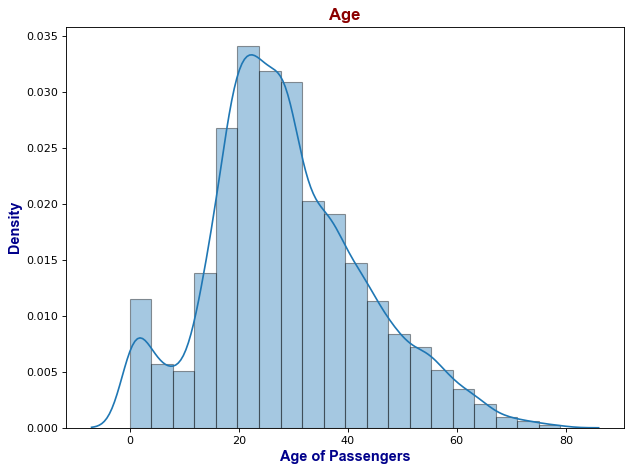

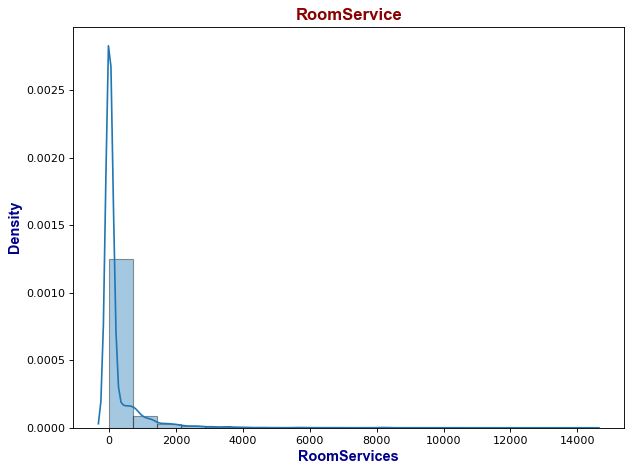

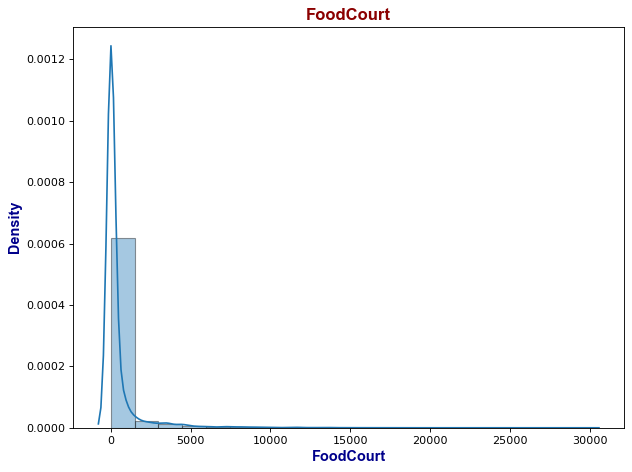

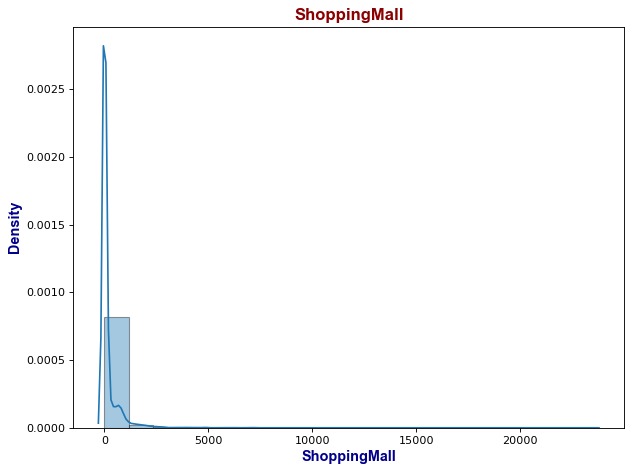

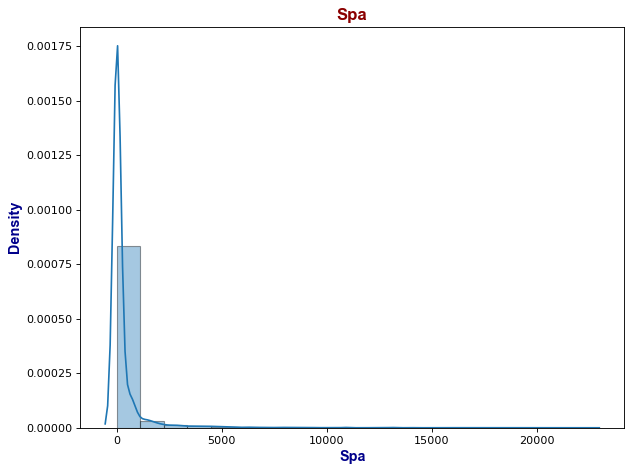

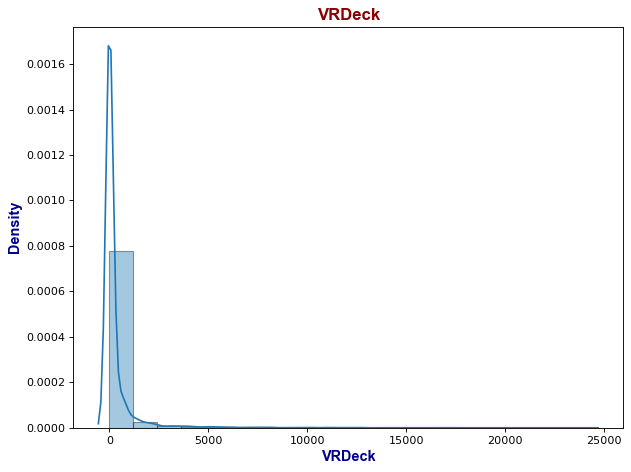

In [17]:
title_font={'family': 'arial', 'color': 'darkred', 'weight': 'bold', 'size': 15}
axis_font={'family': 'arial', 'color': 'darkblue', 'weight': 'bold', 'size': 13}

for i, z in list(zip(numerical_cols, numeric_col_axis)):
    plt.figure(figsize=(8,6),dpi=80)
    sns.distplot(train[i],hist_kws=dict(linewidth=1,edgecolor='k'),bins=20)
    plt.title(i,fontdict=title_font)
    plt.xlabel(z,fontdict=axis_font)
    plt.ylabel('Density',fontdict=axis_font)
    plt.tight_layout()
    plt.show()

**the numerical col tend to have skewness to the right**

<Axes: xlabel='Age', ylabel='Destination'>

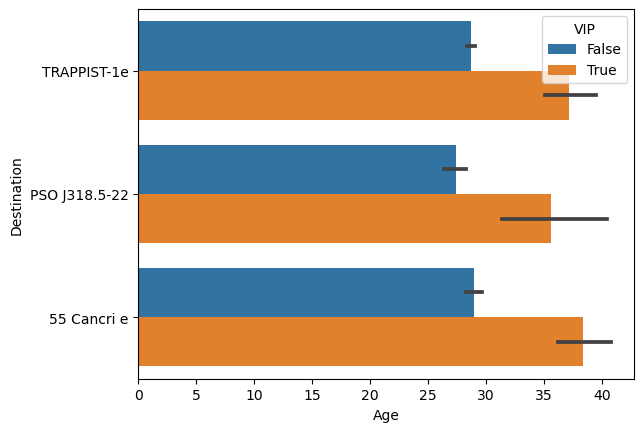

In [18]:
sns.barplot(x= train.Age, y= train.Destination, hue=train.VIP)

## PreProcessing

**Getting Dummies for categorical features**

In [19]:
train_copy=train.copy()
test_copy =test.copy()

In [20]:
train_copy=pd.get_dummies(train_copy,columns=categorical_cols,drop_first=True).astype('int')

test_copy=pd.get_dummies(test_copy,columns=categorical_cols,drop_first=True).astype('int')


**Scaling the numerical features because of their distinctive figures**

In [21]:
standard_scaler=StandardScaler()
scaled_data1= standard_scaler.fit_transform(train[numerical_cols])

In [22]:
standard_scaler=StandardScaler()
scaled_data2= standard_scaler.fit_transform(test[numerical_cols])

In [23]:
scaled_data1

array([[ 0.70943692, -0.33310466, -0.28102673, -0.28357863, -0.2706259 ,
        -0.26300329],
       [-0.33671733, -0.16807343, -0.27538657, -0.24177071,  0.21715825,
        -0.22420468],
       [ 2.03456565, -0.2680006 ,  1.95999765, -0.28357863,  5.69562289,
        -0.21979574],
       ...,
       [-0.1972301 , -0.33310466, -0.28102673,  2.84699872, -0.26973741,
        -0.26300329],
       [ 0.2212316 , -0.33310466,  0.37636549, -0.28357863,  0.04301309,
         2.58957649],
       [ 1.05815501, -0.14233462,  2.656871  , -0.28357863, -0.2706259 ,
        -0.25242185]])

In [24]:
df_scaled=pd.DataFrame(scaled_data1,columns=numerical_cols)
df_scaled.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0.709437,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003
1,-0.336717,-0.168073,-0.275387,-0.241771,0.217158,-0.224205
2,2.034566,-0.268001,1.959998,-0.283579,5.695623,-0.219796
3,0.290975,-0.333105,0.523010,0.336851,2.687176,-0.092818
4,-0.894666,0.125652,-0.237159,-0.031059,0.231374,-0.261240


In [25]:
df_scaled2=pd.DataFrame(scaled_data2,columns=numerical_cols)
df_scaled2.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,-0.118222,-0.357339,-0.283840,-0.312173,-0.267841,-0.246712
1,-0.688601,-0.357339,-0.277879,-0.312173,2.287504,-0.246712
2,0.166968,-0.357339,-0.283840,-0.312173,-0.267841,-0.246712
3,0.666051,-0.357339,4.121518,-0.312173,-0.104002,0.226648
4,-0.617304,-0.340723,-0.283840,0.832122,-0.267841,-0.246712


In [26]:
train_copy.drop(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'],axis=1,inplace=True)

In [27]:
train_new=pd.concat([df_scaled, train_copy.loc[:]], axis=1)
train_new

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True
0,0.709437,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,0,1,0,0,0,1,0
1,-0.336717,-0.168073,-0.275387,-0.241771,0.217158,-0.224205,1,0,0,0,0,1,0
2,2.034566,-0.268001,1.959998,-0.283579,5.695623,-0.219796,0,1,0,0,0,1,1
3,0.290975,-0.333105,0.523010,0.336851,2.687176,-0.092818,0,1,0,0,0,1,0
4,-0.894666,0.125652,-0.237159,-0.031059,0.231374,-0.261240,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0.848924,-0.333105,3.992336,-0.283579,1.189173,-0.197751,0,1,0,0,0,0,1
8689,-0.755179,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,0,0,0,1,1,0,0
8690,-0.197230,-0.333105,-0.281027,2.846999,-0.269737,-0.263003,1,0,0,0,0,1,0
8691,0.221232,-0.333105,0.376365,-0.283579,0.043013,2.589576,0,1,0,0,0,0,0


In [28]:
test_copy.drop(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'],axis=1,inplace=True)

In [29]:
test_new =pd.concat([df_scaled2, test_copy.loc[:]], axis=1)
test_new

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True
0,-1.182216e-01,-0.357339,-0.283840,-0.312173,-0.267841,-0.246712,0,0,1,0,1,0
1,-6.886014e-01,-0.357339,-0.277879,-0.312173,2.287504,-0.246712,0,0,0,0,1,0
2,1.669682e-01,-0.357339,-0.283840,-0.312173,-0.267841,-0.246712,1,0,1,0,0,0
3,6.660505e-01,-0.357339,4.121518,-0.312173,-0.104002,0.226648,1,0,0,0,1,0
4,-6.173039e-01,-0.340723,-0.283840,0.832122,-0.267841,-0.246712,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4272,3.808606e-01,-0.357339,-0.283840,-0.312173,-0.267841,-0.246712,0,0,1,0,1,0
4273,9.512404e-01,-0.357339,0.277095,-0.281538,-0.258790,-0.130193,0,0,0,0,1,0
4274,-2.532995e-16,-0.357339,-0.283840,-0.312173,-0.267841,-0.246712,0,1,1,0,0,0
4275,-2.532995e-16,-0.357339,1.491019,-0.312173,-0.267841,0.176479,1,0,0,0,1,0


train_new['Transported']= train_new.Transported.apply(lambda x: True if x==1 else False)

In [30]:
train_new

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True
0,0.709437,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,0,1,0,0,0,1,0
1,-0.336717,-0.168073,-0.275387,-0.241771,0.217158,-0.224205,1,0,0,0,0,1,0
2,2.034566,-0.268001,1.959998,-0.283579,5.695623,-0.219796,0,1,0,0,0,1,1
3,0.290975,-0.333105,0.523010,0.336851,2.687176,-0.092818,0,1,0,0,0,1,0
4,-0.894666,0.125652,-0.237159,-0.031059,0.231374,-0.261240,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0.848924,-0.333105,3.992336,-0.283579,1.189173,-0.197751,0,1,0,0,0,0,1
8689,-0.755179,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,0,0,0,1,1,0,0
8690,-0.197230,-0.333105,-0.281027,2.846999,-0.269737,-0.263003,1,0,0,0,0,1,0
8691,0.221232,-0.333105,0.376365,-0.283579,0.043013,2.589576,0,1,0,0,0,0,0


## Modelling

In [31]:
#splitting data
X = train_new.drop(['Transported'], axis=1)
y = train_new['Transported']
X_test = test_new
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, random_state=42)

In [32]:
X_test.shape , X_train.shape


((4277, 12), (6954, 12))

In [33]:

# Creating a dictionary of modelS
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVC": SVC(),
    "LGBM": LGBMClassifier(),
    "XGBOOST": XGBClassifier(),
    "CatBoost": CatBoostClassifier(),
    "NaiveBayes": GaussianNB()}

# Creating a function to make predictions using the trained models
def fit_and_score(models, X_train, X_valid, y_train, y_valid):
    """
    Makes predictions using given machine learning models
    models: a dict of different sklearn machine learning models with hyperparameter grids
    X_train: training data
    X_test: testing data
    y_train: training labels
    """
    #set rabdom seed
    #np.random.seed(42)
    #make a dictionary ro keep model score
    model_scores={}
    #loop through models
    for name,model in models.items():
        #fit the model to the data
        model.fit(X_train,y_train)
        #score the model
        model_scores[name]=model.score(X_valid, y_valid)
    return model_scores

In [34]:
model_scores=fit_and_score(models=models, X_train=X_train, X_valid=X_valid, y_train=y_train,y_valid=y_valid)
model_scores

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3500, number of negative: 3454
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001584 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1367
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503307 -> initscore=0.013230
[LightGBM] [Info] Start training from score 0.013230
Learning rate set to 0.023581
0:	learn: 0.6806473	total: 172ms	remaining: 2m 52s
1:	learn: 0.6709795	total: 178ms	remaining: 1m 28s
2:	learn: 0.6598916	total: 184ms	remaining: 1m 1s
3:	learn: 0.6513083	total: 189ms	remaining: 47.1s
4:	learn: 0.6431281	total: 195ms	remaining: 38.9s
5:	learn: 0.6337593	total: 202ms	remaining: 33.4s
6:	learn: 0.6264810	total: 207ms	re

{'Logistic Regression': 0.7757331799884991,
 'KNN': 0.7642323174238068,
 'Random Forest': 0.7780333525014376,
 'SVC': 0.7832087406555491,
 'LGBM': 0.7866589994249569,
 'XGBOOST': 0.7918343875790684,
 'CatBoost': 0.7872340425531915,
 'NaiveBayes': 0.7004025301897643}

In [35]:
model_scores

{'Logistic Regression': 0.7757331799884991,
 'KNN': 0.7642323174238068,
 'Random Forest': 0.7780333525014376,
 'SVC': 0.7832087406555491,
 'LGBM': 0.7866589994249569,
 'XGBOOST': 0.7918343875790684,
 'CatBoost': 0.7872340425531915,
 'NaiveBayes': 0.7004025301897643}

**XGBoost**

In [36]:
param_grid = {'n_estimators': [10, 25, 50, 75, 100],
              'learning_rate': [0.2, 0.15, 0.1, 0.05],
              'eval_metric': ['mlogloss'], 'max_depth': [None, 4, 8, 12], 'objective': ['binary:logistic'], 'num_leaves':[100]}
grid = GridSearchCV(XGBClassifier(), param_grid=param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
best_params = grid.best_params_
print('Best score of cross validation: {:.2f}'.format(grid.best_score_))
print('Best parameters:', best_params)


Best score of cross validation: 0.80
Best parameters: {'eval_metric': 'mlogloss', 'learning_rate': 0.15, 'max_depth': 8, 'n_estimators': 50, 'num_leaves': 100, 'objective': 'binary:logistic'}


In [37]:
xgboost = XGBClassifier(objective='binary:logistic', eval_metreic='logloss',learning_rate=0.15, max_depth=8,n_estimatrs=100,n_jobs=-1,num_leaves= 100)
xgboost.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metreic='logloss',
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.15, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_estimatrs=100,
              n_jobs=-1, ...)

In [38]:
y_pred=xgboost.predict(X_test)

In [39]:
y_pred

array([1, 0, 1, ..., 1, 1, 0])

In [40]:
submission = pd.read_csv('sample_submission.csv')

In [41]:
xgboost_model= pd.DataFrame({'PassengerId':submission.PassengerId,'Transported':y_pred})

In [42]:
xgboost_model

,PassengerId,Transported
0,0013_01,1
1,0018_01,0
2,0019_01,1
3,0021_01,1
4,0023_01,0
...,...,...
4272,9266_02,1
4273,9269_01,0
4274,9271_01,1
4275,9273_01,1


In [43]:
xgboost_model['Transported']= xgboost_model.Transported.apply(lambda x: True if x==1 else False)

In [44]:
xgboost_model.to_csv('submission.csv', index= False)

In [45]:
pd.read_csv('submission.csv').shape

(4277, 2)